<a href="https://colab.research.google.com/github/jwliu24/Uber-Operational-Analysis/blob/main/Week_7_Data_Storytelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uber Rides 2024 — Findings Report

Run this notebook top to bottom. The final cell saves `findings_report.html` — open it in any browser to present.

**Three findings:**
1. Driver cancellations account for 18% of all bookings — the largest single source of lost rides
2. Rides with longer driver arrival times are more likely to be cancelled by the customer
3. Most customer cancellations have an identifiable, fixable cause

See the **Assumptions & Limitations** section at the end before sharing this report with anyone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import io, base64
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
    'font.size':          11,
})

print('ready')

ready


In [2]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/uber_rides_data_processed.csv'


df = pd.read_csv(file_path)

df['Date']       = pd.to_datetime(df['Date'], errors='coerce')
df['datetime']   = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce')
df['hour']       = df['datetime'].dt.hour
df['year_month'] = df['datetime'].dt.to_period('M')

completed     = df[df['Booking Status'] == 'Completed'].copy()
ARPR          = completed['Booking Value'].mean()
total_revenue = completed['Booking Value'].sum()

n_total       = len(df)
n_completed   = len(completed)
n_drv_cancel  = (df['Booking Status'] == 'Cancelled by Driver').sum()
n_cust_cancel = (df['Booking Status'] == 'Cancelled by Customer').sum()
n_no_driver   = (df['Booking Status'] == 'No Driver Found').sum()
n_incomplete  = (df['Booking Status'] == 'Incomplete').sum()

cust_reasons  = df['Reason for cancelling by Customer'].value_counts()
drv_reasons   = df['Driver Cancellation Reason'].value_counts()

monthly_dc    = df[df['Booking Status'] == 'Cancelled by Driver'].groupby('year_month').size().reset_index(name='dc')
monthly_total = df.groupby('year_month').size().reset_index(name='total')
monthly       = monthly_total.merge(monthly_dc, on='year_month', how='left').fillna(0)
monthly['dc_rate'] = monthly['dc'] / monthly['total'] * 100
monthly['label']   = monthly['year_month'].astype(str).str[-5:]

# VTAT — available for all rides except No Driver Found
vtat_df = df[df['Avg VTAT'].notna()].copy()
vtat_df['is_cust_cancel'] = (vtat_df['Booking Status'] == 'Cancelled by Customer').astype(int)
vtat_df['bucket'] = pd.cut(vtat_df['Avg VTAT'],
    bins=[0, 5, 8, 11, 15, 25],
    labels=['0-5 min', '5-8 min', '8-11 min', '11-15 min', 'Over 15 min'])
cancel_by_wait = vtat_df.groupby('bucket', observed=False)['is_cust_cancel'].mean() * 100

avg_vtat_completed = completed['Avg VTAT'].dropna().mean()
avg_vtat_cust_cancel = df[df['Booking Status'] == 'Cancelled by Customer']['Avg VTAT'].dropna().mean()
vtat_corr = vtat_df[['Avg VTAT', 'is_cust_cancel']].corr().iloc[0, 1]

print(f'Loaded {n_total:,} rides')
print(f'Completed: {n_completed:,} ({n_completed/n_total*100:.0f}%)  |  ARPR: ₹{ARPR:.0f}  |  Revenue: ₹{total_revenue:,.0f}')
print(f'Driver cancellations: {n_drv_cancel:,} ({n_drv_cancel/n_total*100:.0f}%)')
print(f'Avg VTAT — completed: {avg_vtat_completed:.1f} min  |  customer cancelled: {avg_vtat_cust_cancel:.1f} min')
print(f'VTAT-cancellation correlation: {vtat_corr:.2f}')

Mounted at /content/drive
Loaded 150,000 rides
Completed: 93,000 (62%)  |  ARPR: ₹508  |  Revenue: ₹47,260,574
Driver cancellations: 27,000 (18%)
Avg VTAT — completed: 8.5 min  |  customer cancelled: 12.5 min
VTAT-cancellation correlation: 0.31


---
## Finding 1: Driver Cancellations Are the Largest Single Source of Lost Rides

**27,000 rides — 18% of all bookings — were cancelled by the driver after accepting.**

This is the largest category of ride loss in the dataset, larger than customer cancellations, no-driver events, and incomplete rides combined.

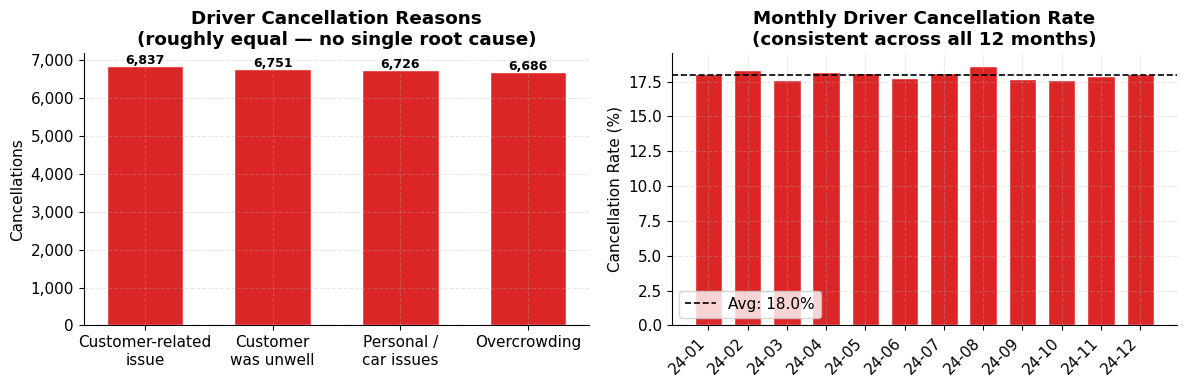

Driver cancellations: 27,000 (18% of all bookings)
Monthly rate range: 17.6% – 18.6% (very stable)

All four reasons appear in roughly equal measure (~25% each).
The rate is consistent across every month — this is a structural problem, not seasonal.

NOTE: We do not have a revenue figure for these lost rides. Cancelled rides have no
Booking Value in the data. Any revenue estimate requires an assumption about what
each ride would have earned — see Assumptions & Limitations section.

Recommendation: introduce a driver performance programme.
Track cancellation rates per driver. Engage highest-cancelling drivers.
Owner: Driver Operations


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Reasons
short_labels = ['Customer-related\nissue', 'Customer\nwas unwell', 'Personal /\ncar issues', 'Overcrowding']
axes[0].bar(short_labels, drv_reasons.values, color='#dc2626', edgecolor='white', width=0.6)
axes[0].set_title('Driver Cancellation Reasons\n(roughly equal — no single root cause)', fontweight='bold')
axes[0].set_ylabel('Cancellations')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=9, fontweight='bold')

# Monthly rate
avg_rate = monthly['dc_rate'].mean()
axes[1].bar(monthly['label'], monthly['dc_rate'], color='#dc2626', edgecolor='white', width=0.7)
axes[1].axhline(avg_rate, color='black', linestyle='--', linewidth=1.2, label=f'Avg: {avg_rate:.1f}%')
axes[1].set_title('Monthly Driver Cancellation Rate\n(consistent across all 12 months)', fontweight='bold')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xticklabels(monthly['label'], rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Driver cancellations: {n_drv_cancel:,} ({n_drv_cancel/n_total*100:.0f}% of all bookings)')
print(f'Monthly rate range: {monthly["dc_rate"].min():.1f}% – {monthly["dc_rate"].max():.1f}% (very stable)')
print()
print('All four reasons appear in roughly equal measure (~25% each).')
print('The rate is consistent across every month — this is a structural problem, not seasonal.')
print()
print('NOTE: We do not have a revenue figure for these lost rides. Cancelled rides have no')
print('Booking Value in the data. Any revenue estimate requires an assumption about what')
print('each ride would have earned — see Assumptions & Limitations section.')
print()
print('Recommendation: introduce a driver performance programme.')
print('Track cancellation rates per driver. Engage highest-cancelling drivers.')
print('Owner: Driver Operations')

---
## Finding 2: Rides with Longer Driver Arrival Times Are More Likely to Be Cancelled

**Customer-cancelled rides have an average driver arrival time of 12.5 minutes, compared to 8.5 minutes for completed rides — a 4-minute difference.**

There is a moderate positive correlation (r = 0.31) between VTAT and customer cancellation. Shorter waits are associated with better outcomes.

> ⚠️ **Important caveat:** This dataset appears to cap VTAT at 15 minutes for completed rides and allows it to go up to 20 minutes for cancelled rides. This means the pattern at the high end of the VTAT range is likely a feature of how the data was generated, not a clean behavioural observation. The overall direction — longer waits correlate with more cancellations — is plausible and worth investigating with real operational data, but the specific upper threshold should not be treated as a hard finding.

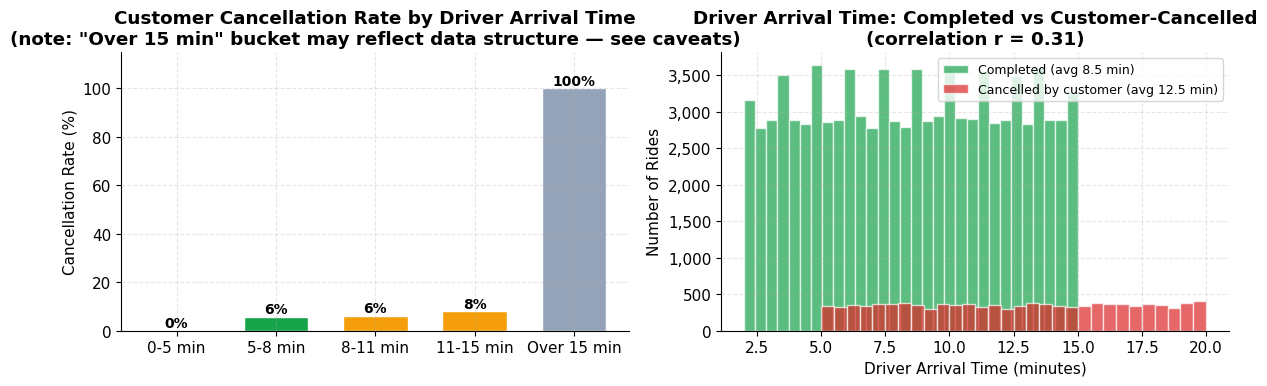

Avg VTAT — completed rides:          8.5 min
Avg VTAT — customer-cancelled rides: 12.5 min
Difference:                          4.0 min
Correlation (VTAT vs cancellation):  r = 0.31 (moderate positive)

VTAT max values by booking status reveal a data anomaly:
  Completed                           max VTAT = 15 min
  Cancelled by Customer               max VTAT = 20 min
  Cancelled by Driver                 max VTAT = 12 min
  Incomplete                          max VTAT = 10 min

Completed rides are capped at 15 min. Customer-cancelled go to 20 min.
This hard boundary is likely a feature of the synthetic dataset, not real behaviour.
The 100% cancellation rate for VTAT > 15 min follows from this boundary, not from customers.

What we can say with confidence: longer arrival times are associated with higher cancellation.
What needs real data to confirm: whether there is a specific threshold that matters.

Recommendation: monitor VTAT distribution in live data. If a clear increase in
cance

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cancellation rate by wait bucket — label the chart honestly
bar_colors = ['#16a34a', '#16a34a', '#f59e0b', '#f59e0b', '#94a3b8']
axes[0].bar(cancel_by_wait.index, cancel_by_wait.values, color=bar_colors, edgecolor='white', width=0.65)
axes[0].set_title('Customer Cancellation Rate by Driver Arrival Time\n'
                  '(note: "Over 15 min" bucket may reflect data structure — see caveats)',
                  fontweight='bold')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_ylim(0, 115)
for bar, val in zip(axes[0].patches, cancel_by_wait.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold')

# VTAT distribution — completed vs customer cancelled
axes[1].hist(completed['Avg VTAT'].dropna(), bins=30, alpha=0.7,
             color='#16a34a', label=f'Completed (avg {avg_vtat_completed:.1f} min)', edgecolor='white')
axes[1].hist(df[df['Booking Status'] == 'Cancelled by Customer']['Avg VTAT'].dropna(),
             bins=30, alpha=0.7,
             color='#dc2626', label=f'Cancelled by customer (avg {avg_vtat_cust_cancel:.1f} min)', edgecolor='white')
axes[1].set_title('Driver Arrival Time: Completed vs Customer-Cancelled\n'
                  f'(correlation r = {vtat_corr:.2f})',
                  fontweight='bold')
axes[1].set_xlabel('Driver Arrival Time (minutes)')
axes[1].set_ylabel('Number of Rides')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print(f'Avg VTAT — completed rides:          {avg_vtat_completed:.1f} min')
print(f'Avg VTAT — customer-cancelled rides: {avg_vtat_cust_cancel:.1f} min')
print(f'Difference:                          {avg_vtat_cust_cancel - avg_vtat_completed:.1f} min')
print(f'Correlation (VTAT vs cancellation):  r = {vtat_corr:.2f} (moderate positive)')
print()
print('VTAT max values by booking status reveal a data anomaly:')
for s in ['Completed', 'Cancelled by Customer', 'Cancelled by Driver', 'Incomplete']:
    v = df[df['Booking Status'] == s]['Avg VTAT'].dropna()
    print(f'  {s:<35} max VTAT = {v.max():.0f} min')
print()
print('Completed rides are capped at 15 min. Customer-cancelled go to 20 min.')
print('This hard boundary is likely a feature of the synthetic dataset, not real behaviour.')
print('The 100% cancellation rate for VTAT > 15 min follows from this boundary, not from customers.')
print()
print('What we can say with confidence: longer arrival times are associated with higher cancellation.')
print('What needs real data to confirm: whether there is a specific threshold that matters.')
print()
print('Recommendation: monitor VTAT distribution in live data. If a clear increase in')
print('cancellation rate at higher wait times is confirmed, implement proactive reassignment.')
print('Owner: Product Engineering (pending validation with live data)')

---
## Finding 3: Most Customer Cancellations Have an Identifiable, Fixable Cause

**Of 10,500 customer cancellations, only 22% are genuine user decisions (change of plans). The remaining 78% have a stated reason that points to a product, policy, or operational failure.**

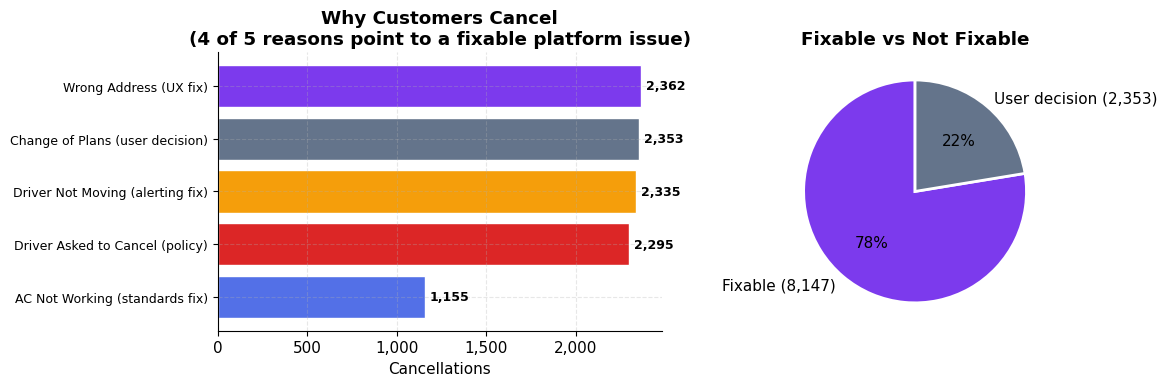

Total customer cancellations: 10,500
With a fixable cause: 8,147 (78%)
Genuine user decision: 2,353 (22%)

What each reason suggests:
  Wrong Address (2,362): customer entered wrong pickup — map confirmation UX
  Driver Not Moving (2,335): driver inactive — alerting or accountability
  Driver Asked to Cancel (2,295): policy violation — in-app reporting
  AC Not Working (1,155): vehicle condition — pre-shift checks

NOTE: These are self-reported reasons. We cannot verify that each label is accurate.
Customers may use the nearest available reason rather than the precise one.
The categories provide useful direction, not exact counts of each root cause.

Recommendation: start with the map confirmation UX fix — highest count, quickest build.
Owner: Product Design


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

short = {
    'Wrong Address':                                'Wrong Address (UX fix)',
    'Change of plans':                              'Change of Plans (user decision)',
    'Driver is not moving towards pickup location': 'Driver Not Moving (alerting fix)',
    'Driver asked to cancel':                       'Driver Asked to Cancel (policy)',
    'AC is not working':                            'AC Not Working (standards fix)',
}
clr_map = {
    'Wrong Address':                                '#7c3aed',
    'Change of plans':                              '#64748b',
    'Driver is not moving towards pickup location': '#f59e0b',
    'Driver asked to cancel':                       '#dc2626',
    'AC is not working':                            '#5370E7',
}
axes[0].barh([short[r] for r in cust_reasons.index], cust_reasons.values,
             color=[clr_map[r] for r in cust_reasons.index], edgecolor='white')
axes[0].set_title('Why Customers Cancel\n(4 of 5 reasons point to a fixable platform issue)', fontweight='bold')
axes[0].set_xlabel('Cancellations')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].tick_params(axis='y', labelsize=9)
for bar, val in zip(axes[0].patches, cust_reasons.values):
    axes[0].text(val + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')

fixable   = cust_reasons.drop('Change of plans').sum()
unfixable = cust_reasons['Change of plans']
axes[1].pie(
    [fixable, unfixable],
    labels=[f'Fixable ({fixable:,})', f'User decision ({unfixable:,})'],
    colors=['#7c3aed', '#64748b'],
    autopct='%1.0f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Fixable vs Not Fixable', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Total customer cancellations: {n_cust_cancel:,}')
print(f'With a fixable cause: {fixable:,} ({fixable/n_cust_cancel*100:.0f}%)')
print(f'Genuine user decision: {unfixable:,} ({unfixable/n_cust_cancel*100:.0f}%)')
print()
print('What each reason suggests:')
print(f'  Wrong Address ({cust_reasons["Wrong Address"]:,}): customer entered wrong pickup — map confirmation UX')
print(f'  Driver Not Moving ({cust_reasons["Driver is not moving towards pickup location"]:,}): driver inactive — alerting or accountability')
print(f'  Driver Asked to Cancel ({cust_reasons["Driver asked to cancel"]:,}): policy violation — in-app reporting')
print(f'  AC Not Working ({cust_reasons["AC is not working"]:,}): vehicle condition — pre-shift checks')
print()
print('NOTE: These are self-reported reasons. We cannot verify that each label is accurate.')
print('Customers may use the nearest available reason rather than the precise one.')
print('The categories provide useful direction, not exact counts of each root cause.')
print()
print('Recommendation: start with the map confirmation UX fix — highest count, quickest build.')
print('Owner: Product Design')

---
## Assumptions, Limitations & Potential Biases

This section should be read before acting on any finding in this report.

In [6]:
print('=== ASSUMPTIONS ===')
print()
print('1. Revenue opportunity estimates')
print('   Cancelled rides have no Booking Value in the data — no fare was ever charged.')
print('   Any revenue figure attached to lost rides (e.g. 27,000 × ₹508 = ₹13.7M) is constructed')
print('   by applying the average revenue from completed rides to the count of cancellations.')
print('   This assumes cancelled rides would have earned the same average as completed rides.')
print('   That assumption may not hold: cancelled rides may skew shorter (lower fare) or')
print('   be concentrated in lower-demand zones. Treat any revenue figure as directional only.')
print()
print('2. VTAT as a booking-time signal')
print('   The Week 5 analysis treated Avg VTAT as available at booking time (a dispatch estimate).')
print('   However, the column may record the actual arrival time after the fact, which would')
print('   make it unavailable for real-time prediction. The column definition is not documented.')
print('   This needs to be confirmed with whoever generated or owns the dataset.')
print()
print('3. Customer cancellation reasons are self-reported')
print('   Customers select from a dropdown. They may choose the closest option rather than')
print('   the precise one. "Wrong Address" may include rides cancelled for unrelated reasons.')
print('   The categories provide useful direction but not exact root cause counts.')
print()
print('=== DATA LIMITATIONS ===')
print()
print('4. Synthetic dataset')
print('   This dataset was synthetically generated. Several patterns that look like findings')
print('   are more likely artifacts of how the data was constructed:')
print('   - VTAT is capped at exactly 15 min for completed rides and goes to 20 min for')
print('     customer-cancelled rides. This hard boundary does not reflect real behaviour —')
print('     it means the "100% cancel rate above 15 min" observation is a data boundary,')
print('     not a customer decision threshold.')
print('   - All four driver cancellation reasons appear in almost exactly equal proportions.')
print('     In real data, reasons rarely distribute this evenly — this uniformity suggests')
print('     random assignment rather than recorded behaviour.')
print('   - Customer cancellation reasons also appear in near-equal proportions (~22% each).')
print('     Same concern applies.')
print()

unique_customers = df['Customer ID'].nunique()
returning = (df.groupby('Customer ID').size() >= 2).sum()
print('5. Retention data is not meaningful')
print(f'   {unique_customers:,} unique customers across {n_total:,} rides — almost every customer')
print(f'   appears only once ({returning:,} returned, {returning/unique_customers*100:.1f}%). This is unrealistic')
print('   for a real platform and makes any retention analysis uninformative.')
print('   No retention finding should be drawn from this dataset.')
print()
print('6. No external context')
print('   The dataset covers one calendar year with no information about:')
print('   - Marketing campaigns, pricing changes, or promotions')
print('   - Competitor activity or market events')
print('   - Geography beyond pickup/drop location names')
print('   - Driver demographics, tenure, or vehicle age')
print('   Without this context, we can describe patterns but cannot explain causes.')
print()
print('=== POTENTIAL BIASES ===')
print()
print('7. Survivorship in ARPR')
print('   Average Revenue Per Ride is calculated from completed rides only.')
print('   Rides that were cancelled may have had different characteristics — shorter distance,')
print('   different vehicle type, different time of day — that would change the average.')
print('   ARPR from completed rides is not a neutral baseline for all 150,000 bookings.')
print()
print('8. Reporting bias in cancellation reasons')
print('   Customers who cancel because of driver behaviour ("driver asked to cancel") may')
print('   underreport this if they fear retaliation or do not trust the platform to act.')
print('   The true count of policy violations is likely higher than what is recorded.')
print()
print('9. Confirmation in recommendations')
print('   Recommendations in this report were generated by looking at what the data showed')
print('   and reasoning backwards to a fix. This is vulnerable to confirmation bias —')
print('   the recommended interventions feel obvious because we designed them to fit the pattern.')
print('   Each recommendation should be tested (A/B test or pilot) before full rollout.')

=== ASSUMPTIONS ===

1. Revenue opportunity estimates
   Cancelled rides have no Booking Value in the data — no fare was ever charged.
   Any revenue figure attached to lost rides (e.g. 27,000 × ₹508 = ₹13.7M) is constructed
   by applying the average revenue from completed rides to the count of cancellations.
   This assumes cancelled rides would have earned the same average as completed rides.
   That assumption may not hold: cancelled rides may skew shorter (lower fare) or
   be concentrated in lower-demand zones. Treat any revenue figure as directional only.

2. VTAT as a booking-time signal
   The Week 5 analysis treated Avg VTAT as available at booking time (a dispatch estimate).
   However, the column may record the actual arrival time after the fact, which would
   make it unavailable for real-time prediction. The column definition is not documented.
   This needs to be confirmed with whoever generated or owns the dataset.

3. Customer cancellation reasons are self-reported
   

---
## Summary

In [7]:
wrong_addr = cust_reasons['Wrong Address']

print('What the data shows:')
print(f'  - {n_drv_cancel:,} rides ({n_drv_cancel/n_total*100:.0f}%) cancelled by drivers — consistent all year, no single cause')
print(f'  - Customer-cancelled rides have higher avg VTAT ({avg_vtat_cust_cancel:.1f} min) than completed ({avg_vtat_completed:.1f} min)')
print(f'  - {fixable:,} of {n_cust_cancel:,} customer cancellations ({fixable/n_cust_cancel*100:.0f}%) have a stated fixable cause')
print()
print('Recommended next steps:')
print(f'  1. Driver performance programme  — {n_drv_cancel:,} rides affected  |  Owner: Driver Operations')
print(f'  2. Monitor VTAT in live data, then assess reassignment thresholds  |  Owner: Product Engineering')
print(f'  3. Map pin confirmation UX fix  — {wrong_addr:,} rides affected  |  Owner: Product Design')
print()
print('What this report cannot tell us:')
print('  - Exact revenue lost (no fare recorded for cancelled rides)')
print('  - Whether VTAT patterns reflect real customer behaviour or data construction')
print('  - Whether fixing each cause would actually prevent the cancellation')
print('  - How findings would differ in real operational data vs this synthetic dataset')

What the data shows:
  - 27,000 rides (18%) cancelled by drivers — consistent all year, no single cause
  - Customer-cancelled rides have higher avg VTAT (12.5 min) than completed (8.5 min)
  - 8,147 of 10,500 customer cancellations (78%) have a stated fixable cause

Recommended next steps:
  1. Driver performance programme  — 27,000 rides affected  |  Owner: Driver Operations
  2. Monitor VTAT in live data, then assess reassignment thresholds  |  Owner: Product Engineering
  3. Map pin confirmation UX fix  — 2,362 rides affected  |  Owner: Product Design

What this report cannot tell us:
  - Exact revenue lost (no fare recorded for cancelled rides)
  - Whether VTAT patterns reflect real customer behaviour or data construction
  - Whether fixing each cause would actually prevent the cancellation
  - How findings would differ in real operational data vs this synthetic dataset


---
## Export as HTML

Saves `findings_report.html` — open in any browser, use F11 for fullscreen.

In [8]:
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

# ── Chart 1a: driver reasons ────────────────────────────────────────────────
fig1a, ax = plt.subplots(figsize=(7, 3.5))
short_labels = ['Customer-related\nissue', 'Customer\nwas unwell', 'Personal /\ncar issues', 'Overcrowding']
ax.bar(short_labels, drv_reasons.values, color='#dc2626', edgecolor='white', width=0.6)
ax.set_title('Driver Cancellation Reasons (each ~25%)', fontweight='bold')
ax.set_ylabel('Cancellations')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{bar.get_height():,.0f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); img1a = fig_to_base64(fig1a); plt.close(fig1a)

# ── Chart 1b: monthly rate ──────────────────────────────────────────────────
fig1b, ax = plt.subplots(figsize=(7, 3.5))
avg_rate = monthly['dc_rate'].mean()
ax.bar(monthly['label'], monthly['dc_rate'], color='#dc2626', edgecolor='white', width=0.7)
ax.axhline(avg_rate, color='black', linestyle='--', linewidth=1.2, label=f'Avg: {avg_rate:.1f}%')
ax.set_title('Monthly Driver Cancellation Rate', fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.set_xticklabels(monthly['label'], rotation=45, ha='right')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); img1b = fig_to_base64(fig1b); plt.close(fig1b)

# ── Chart 2a: cancel rate by wait bucket ───────────────────────────────────
fig2a, ax = plt.subplots(figsize=(7, 3.5))
bar_colors = ['#16a34a', '#16a34a', '#f59e0b', '#f59e0b', '#94a3b8']
ax.bar(cancel_by_wait.index, cancel_by_wait.values, color=bar_colors, edgecolor='white', width=0.65)
ax.set_title('Customer Cancel Rate by Driver Arrival Time\n(grey = data boundary, not confirmed behaviour)', fontweight='bold')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_ylim(0, 115)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, val in zip(ax.patches, cancel_by_wait.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); img2a = fig_to_base64(fig2a); plt.close(fig2a)

# ── Chart 2b: VTAT distribution ─────────────────────────────────────────────
fig2b, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(completed['Avg VTAT'].dropna(), bins=30, alpha=0.7,
        color='#16a34a', label=f'Completed (avg {avg_vtat_completed:.1f} min)', edgecolor='white')
ax.hist(df[df['Booking Status'] == 'Cancelled by Customer']['Avg VTAT'].dropna(),
        bins=30, alpha=0.7,
        color='#dc2626', label=f'Cancelled (avg {avg_vtat_cust_cancel:.1f} min)', edgecolor='white')
ax.set_title(f'Driver Arrival Time: Completed vs Customer-Cancelled (r = {vtat_corr:.2f})', fontweight='bold')
ax.set_xlabel('Driver Arrival Time (minutes)')
ax.set_ylabel('Rides')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); img2b = fig_to_base64(fig2b); plt.close(fig2b)

# ── Chart 3a: customer reasons ──────────────────────────────────────────────
short = {
    'Wrong Address':                                'Wrong Address (UX fix)',
    'Change of plans':                              'Change of Plans (user decision)',
    'Driver is not moving towards pickup location': 'Driver Not Moving (alerting fix)',
    'Driver asked to cancel':                       'Driver Asked to Cancel (policy)',
    'AC is not working':                            'AC Not Working (standards fix)',
}
clr_map = {'Wrong Address': '#7c3aed', 'Change of plans': '#64748b',
           'Driver is not moving towards pickup location': '#f59e0b',
           'Driver asked to cancel': '#dc2626', 'AC is not working': '#5370E7'}
fig3a, ax = plt.subplots(figsize=(7, 3.5))
ax.barh([short[r] for r in cust_reasons.index], cust_reasons.values,
        color=[clr_map[r] for r in cust_reasons.index], edgecolor='white')
ax.set_title('Why Customers Cancel (self-reported)', fontweight='bold')
ax.set_xlabel('Cancellations')
ax.invert_yaxis(); ax.tick_params(axis='y', labelsize=9)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, val in zip(ax.patches, cust_reasons.values):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout(); img3a = fig_to_base64(fig3a); plt.close(fig3a)

# ── Chart 3b: fixable pie ───────────────────────────────────────────────────
fixable   = cust_reasons.drop('Change of plans').sum()
unfixable = cust_reasons['Change of plans']
fig3b, ax = plt.subplots(figsize=(4, 3.5))
ax.pie([fixable, unfixable],
       labels=[f'Fixable\n({fixable:,})', f'User decision\n({unfixable:,})'],
       colors=['#7c3aed', '#64748b'],
       autopct='%1.0f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Fixable vs Not', fontweight='bold')
plt.tight_layout(); img3b = fig_to_base64(fig3b); plt.close(fig3b)

wrong_addr = cust_reasons['Wrong Address']


# ── Build HTML ───────────────────────────────────────────────────────────────
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Uber Rides 2024 — Findings Report</title>
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
          background: #f1f5f9; color: #1e293b; }}
  .slide {{ min-height: 100vh; padding: 48px 64px; display: flex;
             flex-direction: column; justify-content: center;
             border-bottom: 3px solid #e2e8f0; background: white; }}
  .slide:nth-child(even) {{ background: #f8fafc; }}
  .slide-label {{ font-size: 11px; font-weight: 700; letter-spacing: .12em;
                  text-transform: uppercase; color: #94a3b8; margin-bottom: 12px; }}
  h1 {{ font-size: 32px; font-weight: 700; color: #1e293b; line-height: 1.2; margin-bottom: 8px; }}
  h2 {{ font-size: 26px; font-weight: 700; color: #1e293b; line-height: 1.25; margin-bottom: 8px; }}
  h3 {{ font-size: 17px; font-weight: 700; color: #1e293b; margin: 20px 0 8px; }}
  .subtitle {{ font-size: 16px; color: #64748b; margin-bottom: 24px; }}
  .stats {{ display: flex; gap: 20px; margin: 20px 0; flex-wrap: wrap; }}
  .stat {{ background: #f8fafc; border-left: 4px solid #5370E7;
           padding: 16px 20px; border-radius: 4px; min-width: 150px; }}
  .stat-value {{ font-size: 26px; font-weight: 700; color: #1e293b; }}
  .stat-label {{ font-size: 11px; color: #64748b; margin-top: 4px; font-weight: 600;
                 text-transform: uppercase; letter-spacing: .06em; }}
  .charts {{ display: flex; gap: 20px; margin: 20px 0; flex-wrap: wrap; }}
  .charts img {{ max-width: 100%; border-radius: 4px; border: 1px solid #e2e8f0; }}
  .insight {{ background: #f0f9ff; border-left: 4px solid #0d9488;
              padding: 14px 18px; border-radius: 4px; margin: 14px 0;
              font-size: 14px; line-height: 1.65; }}
  .caveat {{ background: #fffbeb; border-left: 4px solid #f59e0b;
             padding: 14px 18px; border-radius: 4px; margin: 14px 0;
             font-size: 14px; line-height: 1.65; }}
  .caveat strong {{ color: #92400e; }}
  .rec {{ background: #f0fdf4; border-left: 4px solid #16a34a;
          padding: 14px 18px; border-radius: 4px; margin: 14px 0;
          font-size: 14px; line-height: 1.65; }}
  .rec strong {{ color: #15803d; }}
  .limit-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(280px, 1fr));
                 gap: 16px; margin-top: 20px; }}
  .limit-card {{ border: 1px solid #e2e8f0; border-radius: 6px; padding: 16px;
                 background: white; }}
  .limit-card .tag {{ font-size: 10px; font-weight: 700; text-transform: uppercase;
                      letter-spacing: .1em; margin-bottom: 6px; }}
  .limit-card p {{ font-size: 13px; color: #475569; line-height: 1.6; }}
  .assumption .tag {{ color: #5370E7; }}
  .assumption {{ border-top: 3px solid #5370E7; }}
  .limitation .tag {{ color: #dc2626; }}
  .limitation {{ border-top: 3px solid #dc2626; }}
  .bias .tag {{ color: #f59e0b; }}
  .bias {{ border-top: 3px solid #f59e0b; }}
  .rec-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(240px, 1fr));
               gap: 16px; margin-top: 20px; }}
  .rec-card {{ border: 1px solid #e2e8f0; border-radius: 6px; padding: 16px; background: white; }}
  .rec-card .priority {{ font-size: 10px; font-weight: 700; text-transform: uppercase;
                          letter-spacing: .1em; margin-bottom: 6px; }}
  .rec-card h4 {{ font-size: 15px; font-weight: 700; margin-bottom: 6px; color: #1e293b; }}
  .rec-card p {{ font-size: 13px; color: #475569; line-height: 1.55; margin-bottom: 6px; }}
  .rec-card .meta {{ font-size: 12px; color: #94a3b8; }}
  .high {{ border-top: 3px solid #dc2626; }} .high .priority {{ color: #dc2626; }}
  .med  {{ border-top: 3px solid #f59e0b; }} .med  .priority {{ color: #b45309; }}
  .quick {{ border-top: 3px solid #16a34a; }} .quick .priority {{ color: #15803d; }}
  .cover {{ background: #1e293b !important; }}
  .cover h1 {{ color: #5eead4; font-size: 38px; }}
  .cover .subtitle {{ color: #94a3b8; font-size: 17px; }}
  .cover .stat {{ background: #334155; border-left-color: #5eead4; }}
  .cover .stat-value {{ color: #5eead4; }}
  .cover .stat-label {{ color: #94a3b8; }}
</style>
</head>
<body>

<!-- COVER -->
<section class="slide cover">
  <div class="slide-label">Uber Rides 2024 · Analytical Report</div>
  <h1>Where are we losing rides —<br>and what should we do about it?</h1>
  <p class="subtitle">Three findings from 150,000 bookings · Dataset: synthetic · Read limitations section before acting on findings</p>
  <div class="stats">
    <div class="stat"><div class="stat-value">150,000</div><div class="stat-label">Total Bookings</div></div>
    <div class="stat"><div class="stat-value">62%</div><div class="stat-label">Completion Rate</div></div>
    <div class="stat"><div class="stat-value">₹{total_revenue/1e6:.1f}M</div><div class="stat-label">Revenue (completed)</div></div>
    <div class="stat"><div class="stat-value">₹{ARPR:.0f}</div><div class="stat-label">Avg Revenue / Ride</div></div>
  </div>
</section>

<!-- FINDING 1 -->
<section class="slide">
  <div class="slide-label">Finding 1 of 3</div>
  <h2>Driver Cancellations Are the Largest Single Source of Lost Rides</h2>
  <p class="subtitle">{n_drv_cancel:,} rides (18% of all bookings) cancelled by drivers — consistent across all 12 months</p>
  <div class="stats">
    <div class="stat" style="border-left-color:#dc2626"><div class="stat-value">{n_drv_cancel:,}</div><div class="stat-label">Cancelled by Driver</div></div>
    <div class="stat" style="border-left-color:#f59e0b"><div class="stat-value">18%</div><div class="stat-label">of all bookings</div></div>
    <div class="stat" style="border-left-color:#64748b"><div class="stat-value">{monthly['dc_rate'].min():.1f}–{monthly['dc_rate'].max():.1f}%</div><div class="stat-label">Monthly range (very stable)</div></div>
  </div>
  <div class="charts">
    <img src="data:image/png;base64,{img1a}" style="flex:1; min-width:280px;">
    <img src="data:image/png;base64,{img1b}" style="flex:1; min-width:280px;">
  </div>
  <div class="insight">All four reasons appear in roughly equal measure (~25% each). The rate is consistent every month. This is a structural reliability problem, not seasonal and not caused by one thing.</div>
  <div class="caveat"><strong>Note on revenue:</strong> Cancelled rides have no Booking Value recorded. Any figure like &ldquo;₹13.7M lost&rdquo; is constructed by multiplying 27,000 by the average completed-ride revenue. That is an estimate built on an assumption — not a measured loss. See Assumptions section.</div>
  <div class="rec"><strong>Recommendation:</strong> Introduce a driver performance programme. Track cancellation rates per driver. Engage highest-cancelling drivers to understand root causes, then set expectations.<br><em>Owner: Driver Operations</em></div>
</section>

<!-- FINDING 2 -->
<section class="slide">
  <div class="slide-label">Finding 2 of 3</div>
  <h2>Rides with Longer Driver Arrival Times Are More Likely to Be Cancelled</h2>
  <p class="subtitle">Customer-cancelled rides average {avg_vtat_cust_cancel:.1f} min driver arrival time vs {avg_vtat_completed:.1f} min for completed rides (correlation r&nbsp;=&nbsp;{vtat_corr:.2f})</p>
  <div class="stats">
    <div class="stat" style="border-left-color:#16a34a"><div class="stat-value">{avg_vtat_completed:.1f} min</div><div class="stat-label">Avg VTAT — completed</div></div>
    <div class="stat" style="border-left-color:#dc2626"><div class="stat-value">{avg_vtat_cust_cancel:.1f} min</div><div class="stat-label">Avg VTAT — cancelled</div></div>
    <div class="stat" style="border-left-color:#5370E7"><div class="stat-value">r = {vtat_corr:.2f}</div><div class="stat-label">VTAT–cancellation correlation</div></div>
  </div>
  <div class="charts">
    <img src="data:image/png;base64,{img2a}" style="flex:1; min-width:280px;">
    <img src="data:image/png;base64,{img2b}" style="flex:1; min-width:280px;">
  </div>
  <div class="insight">Longer driver arrival times are associated with higher cancellation rates. The direction of the relationship is clear and consistent across buckets.</div>
  <div class="caveat"><strong>Important caveat:</strong> Completed rides in this dataset are capped at exactly 15 minutes VTAT. Customer-cancelled rides go up to 20 minutes. The &ldquo;100% cancellation rate above 15 min&rdquo; result follows from this hard boundary in the data — it is likely an artifact of how the synthetic dataset was generated, not a real customer behaviour threshold. The specific number (15 minutes) should not be acted on without validation against real operational data.</div>
  <div class="rec"><strong>Recommendation:</strong> Monitor VTAT distribution in live operational data. If cancellation rate increases meaningfully above a certain wait time, implement proactive driver reassignment at that threshold.<br><em>Owner: Product Engineering — pending validation with real data</em></div>
</section>

<!-- FINDING 3 -->
<section class="slide">
  <div class="slide-label">Finding 3 of 3</div>
  <h2>Most Customer Cancellations Have an Identifiable, Fixable Cause</h2>
  <p class="subtitle">{fixable:,} of {n_cust_cancel:,} customer cancellations ({fixable/n_cust_cancel*100:.0f}%) cite a reason pointing to a product, policy, or operational failure</p>
  <div class="stats">
    <div class="stat" style="border-left-color:#dc2626"><div class="stat-value">{n_cust_cancel:,}</div><div class="stat-label">Customer Cancellations</div></div>
    <div class="stat" style="border-left-color:#7c3aed"><div class="stat-value">{fixable:,}</div><div class="stat-label">Fixable cause stated</div></div>
    <div class="stat" style="border-left-color:#64748b"><div class="stat-value">{unfixable:,}</div><div class="stat-label">Genuine user decision</div></div>
  </div>
  <div class="charts">
    <img src="data:image/png;base64,{img3a}" style="flex:2; min-width:320px;">
    <img src="data:image/png;base64,{img3b}" style="flex:1; min-width:180px;">
  </div>
  <div class="insight">Four of the five cancellation reasons point to something the platform controls: address display, driver accountability, policy enforcement, or vehicle standards. Only &ldquo;change of plans&rdquo; is a genuine user decision.</div>
  <div class="caveat"><strong>Note:</strong> These are self-reported reasons from a dropdown. Customers may select the nearest option rather than the precise cause. The categories indicate where to look — they are not exact root cause counts. The near-equal distribution across reasons (~22% each) is also atypical for real data and may reflect synthetic generation.</div>
  <div class="rec"><strong>Recommendation:</strong> Start with the map confirmation UX fix — highest count, simplest build, no driver behaviour change required.<br><em>Owner: Product Design</em></div>
</section>

<!-- ASSUMPTIONS & LIMITATIONS -->
<section class="slide">
  <div class="slide-label">Read before acting on any finding</div>
  <h2>Assumptions, Limitations &amp; Potential Biases</h2>
  <div class="limit-grid">
    <div class="limit-card assumption"><div class="tag">Assumption</div>
      <p><strong>Revenue estimates</strong> are constructed by multiplying lost-ride counts by the average completed-ride ARPR (₹{ARPR:.0f}). Cancelled rides have no recorded fare. The assumption that they would have earned the same average is unverified and likely overstated.</p></div>
    <div class="limit-card assumption"><div class="tag">Assumption</div>
      <p><strong>VTAT availability</strong>: the analysis treated Avg VTAT as available at booking time. It may be recorded after the ride, which would make it unavailable for real-time prediction. The column definition needs to be confirmed with the data owner.</p></div>
    <div class="limit-card limitation"><div class="tag">Data Limitation</div>
      <p><strong>Synthetic dataset</strong>: VTAT is capped at 15 min for completed rides but goes to 20 min for cancelled rides — a hard boundary that produced the &ldquo;100% threshold&rdquo; result. Cancellation reason distributions are unrealistically uniform (~25% or ~22% each). These patterns suggest random data generation, not recorded behaviour.</p></div>
    <div class="limit-card limitation"><div class="tag">Data Limitation</div>
      <p><strong>Retention is not measurable</strong>: {unique_customers:,} unique customers across {n_total:,} rides — 99.2% appear only once. Real platforms see 30–70% return within 30 days. No retention insight should be drawn from this dataset.</p></div>
    <div class="limit-card limitation"><div class="tag">Data Limitation</div>
      <p><strong>No external context</strong>: the dataset has no information about pricing changes, marketing campaigns, competitor activity, driver tenure, or geographic demand patterns. We can describe what happened — we cannot explain why.</p></div>
    <div class="limit-card bias"><div class="tag">Potential Bias</div>
      <p><strong>Survivorship in ARPR</strong>: ARPR is calculated from completed rides only. Cancelled rides may skew shorter or cheaper. ARPR from completions is not a neutral baseline for all bookings.</p></div>
    <div class="limit-card bias"><div class="tag">Potential Bias</div>
      <p><strong>Underreporting of driver pressure</strong>: customers who cancel because a driver pressured them may underreport this if they fear retaliation. The true count of policy violations is likely higher than recorded.</p></div>
    <div class="limit-card bias"><div class="tag">Potential Bias</div>
      <p><strong>Confirmation in recommendations</strong>: recommendations were generated by reasoning backwards from patterns. Each should be tested (A/B test or pilot) before full rollout — the intervention feeling obvious does not mean it will work.</p></div>
  </div>
</section>

</body>
</html>"""

output_path = 'findings_report.html'
with open(output_path, 'w') as f:
    f.write(html)

print(f'Saved: {output_path}')
print('Open in any browser. F11 for fullscreen, scroll to move between sections.')

try:
    from google.colab import files
    files.download(output_path)
except ImportError:
    pass

Saved: findings_report.html
Open in any browser. F11 for fullscreen, scroll to move between sections.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>